# Test Classificatori e Valutazione della Sostenibilità
## Real+Augmented vs Real+Synth

Confronto delle prestazioni sul test set composto da 438 immagini reali (365 sani / 73 malati) tra due strategie di addestramento:

| Configurazione | Dati di Training | Riferimento |
|---|---|---|
| **Real+Augmented** | Immagini reali + augmentation tradizionale (geometrica) | Notebook 10 |
| **Real+Synth** | Immagini reali + immagini sintetiche (modelli di diffusione) | Notebook 06 |

- Lo scopo della valutazione è determinare se l'introduzione di dati sintetici migliori le prestazioni del classificatore in maniera tale da giustificarne il costo computazionale ed i relativi consumi energetici.
- Per un confronto equo ed evitare data leakage viene applicato lo stesso preprocessing del training.
- La soglia di Youden viene ricalcolata per entrambi i modelli sul validation set.
- La soglia ottimale viene congelata e applicata alle probabilità del test set.

#### Setup percorsi

In [65]:
import os, sys
from pathlib import Path

#esecuzione su colab (con drive) oppure in locale/WSL
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')                         #monta drive (utile per Colab/prof)
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    #individua la root MammoDiffusion risalendo le cartelle
    cands = [Path.cwd(), *Path.cwd().parents]
    root = next((p for p in cands if (p / 'data' / 'processed').is_dir()), Path.cwd())
    BASE_PATH = f"{root}/"
print("percorso:", BASE_PATH)

percorso: /mnt/c/Users/samto/Desktop/MammoDiffusion/


#### Import e Configurazione GPU

In [66]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   #silenzia i log di TensorFlow 

import zipfile, gdown, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score,
    f1_score, accuracy_score, precision_recall_curve, average_precision_score
)

tf.get_logger().setLevel('ERROR')          #silenzia warning di python

#allocazione dinamica memoria GPU per evitare OOM
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("set_memory_growth:", e)

#### Configurazione
- Definizione dei percorsi per i modelli da valutare `Real+Augmented` e `Real+Synth`, costanti per il preprocessing delle immagini e directory di output.

In [67]:
#percorsi e id drive per modello Real+Augmented
TRAD_AUG_EXP_DIR        = os.path.join(BASE_PATH, 'experiments', 'exp_trad_aug_resnet50')
TRAD_AUG_MODEL_DRIVE_ID = ''      #id drive del .keras 

#percorsi, id drive e soglia per modello Real+Synth
REAL_SYNTH_EXP_DIR              = os.path.join(BASE_PATH, 'experiments', 'exp20260617_real_synth_resnet50_fine_tuned_batch_size_16')
REAL_SYNTH_MODEL_DRIVE_ID       = '11f9pcL8kbLz7hi6i3lqDuferljdRl2uV'
REAL_SYNTH_REF_THRESHOLD_YOUDEN = 0.269

MODELLI_ATTIVI = ['Real+Augmented', 'Real+Synth']     #modelli da valutare

#path e id drive per dataset preprocessato
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
TEST_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'test.csv')
VAL_CSV_PATH  = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'val.csv')

#parametri preprocessing
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

#cartelle di output dedicate per evitare conflitti
OUTPUT_DIR      = os.path.join(BASE_PATH, 'results', 'test_trad_aug_vs_real_synth')
FIGURES_DIR     = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR      = os.path.join(OUTPUT_DIR, 'tables')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')
MODELS_DIR      = os.path.join(OUTPUT_DIR, 'models')

for d in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

#valida lista modelli attivi
_VALIDI = {'Real+Augmented', 'Real+Synth'}
assert 1 <= len(MODELLI_ATTIVI) and set(MODELLI_ATTIVI) <= _VALIDI, "MODELLI_ATTIVI deve essere sottoinsieme di %s" % _VALIDI

print("output in:", OUTPUT_DIR)
print("modelli:", MODELLI_ATTIVI)

output in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth
modelli: ['Real+Augmented', 'Real+Synth']


#### Verifica presenza dataset preprocessato

In [68]:
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')   #percorso archivio zip

#verifica presenza dei file csv e della prima immagine
def verifica_processed_data():
    if not (os.path.isfile(TEST_CSV_PATH) and os.path.isfile(VAL_CSV_PATH)):
        return False
    try:
        first_path = pd.read_csv(TEST_CSV_PATH)['processed_path'].iloc[0]       #legge percorso prima immagine
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

#se dataset mancante esegue download
if not verifica_processed_data():
    print("dataset non trovato - download da drive")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)    #scarica archivio
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))              #estrae contenuto
    os.remove(PROCESSED_ZIP)       
    print("dataset estratto")
else:
    print("dataset gia' presente")

dataset gia' presente


#### Creazione Validation e Test dataset
- Si utilizzano solo immagini reali con preprocessing identico al training.
- La soglia di Youden viene calcolata sul validation set e la valutazione viene svolta sul test set.

In [69]:
#carica e preprocessa singola immagine
def caricamento_preprocessing(percorso, etichetta):
    raw = tf.io.read_file(percorso)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)   #decodifica in grayscale
    img = tf.image.resize(img, IMG_SIZE)                                    #ridimensiona
    img = tf.cast(img, tf.float32) / 255.0                                  #normalizza in range [0,1]
    img = tf.repeat(img, repeats=3, axis=-1)                                #duplica su 3 canali RGB
    img = (img - IMAGENET_MEAN) / IMAGENET_STD                              #normalizza con statistiche ImageNet
    return img, tf.cast(etichetta, tf.float32)

#crea pipeline dati da dataframe
def crea_dataset(df):
    percorsi  = [os.path.join(BASE_PATH, p) for p in df['processed_path'].values] #percorsi delle immagini
    etichette = df['cancer'].values                                         
    ds = tf.data.Dataset.from_tensor_slices((percorsi, etichette))          #crea dataset
    ds = ds.map(lambda p, l: caricamento_preprocessing(p, l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)                          #raggruppa in batch e precarica

#carica dataframe validation e test
df_val  = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)
df_test = pd.read_csv(TEST_CSV_PATH).reset_index(drop=True)

#stampa statistiche classi
print("VAL :", len(df_val), "img  (malato=%d, sano=%d)" % ((df_val['cancer']==1).sum(),  (df_val['cancer']==0).sum()))
print("TEST:", len(df_test), "img  (malato=%d, sano=%d)" % ((df_test['cancer']==1).sum(), (df_test['cancer']==0).sum()))

#istanzia i dataset
val_ds  = crea_dataset(df_val)
test_ds = crea_dataset(df_test)

VAL : 437 img  (malato=73, sano=364)
TEST: 438 img  (malato=73, sano=365)


#### Caricamento modelli
- Caricamento da /experiments, cache o Drive.
- I modelli vengono caricati con `compile=False` poiché verrà eseguita la sola inferenza.

In [70]:
#percorsi e id drive (fallback) dei modelli da valutare
MODELS_CONFIG = {
    'Real+Augmented': {
        'percorso_exp':     os.path.join(TRAD_AUG_EXP_DIR, 'trad_aug_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,       'trad_aug_resnet50_final_best.keras'),
        'drive_id':         TRAD_AUG_MODEL_DRIVE_ID,
    },
    'Real+Synth': {
        'percorso_exp':     os.path.join(REAL_SYNTH_EXP_DIR, 'real_synth_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,         'real_synth_resnet50_final_best.keras'),
        'drive_id':         REAL_SYNTH_MODEL_DRIVE_ID,
    },
}

#carica modello da /experiments, cache locale o download da drive (fallback)
def carica_modello(nome, config):
    if os.path.isfile(config['percorso_exp']):
        print("[%s] caricamento da /experiments" % nome)
        return keras.models.load_model(config['percorso_exp'], compile=False)
    if os.path.isfile(config['percorso_modello']):
        print("[%s] caricamento da cache" % nome)
        return keras.models.load_model(config['percorso_modello'], compile=False)
    if not config['drive_id']:
        raise FileNotFoundError("[%s] modello e id drive mancanti" % nome)
    print("[%s] download da drive" % nome)
    gdown.download(id=config['drive_id'], output=config['percorso_modello'], quiet=False)
    return keras.models.load_model(config['percorso_modello'], compile=False)

modelli = {nome: carica_modello(nome, MODELS_CONFIG[nome]) for nome in MODELLI_ATTIVI}
print("modelli caricati:", list(modelli))


[Real+Augmented] caricamento da /experiments
[Real+Synth] caricamento da /experiments
modelli caricati: ['Real+Augmented', 'Real+Synth']


#### Soglia di Youden
- Per entrambi i modelli la soglia ottimale (punto di Youden) viene calcolata sul validation set.
- La soglia viene congelata e applicata al test set per evitare data leakage.

In [71]:
#estrae probabilità ed etichette da dataset
def predici(modello, dataset):
    y_true, y_prob = [], []
    for imgs, labels in dataset:
        y_prob.extend(modello.predict(imgs, verbose=0).flatten())
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_prob)

#calcola soglia di Youden
def soglia_youden(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return float(thr[np.argmax(tpr - fpr)])

#esegue predizioni su validation set per ricavare soglie
val_true = None
val_probs, soglie = {}, {}
for nome in MODELLI_ATTIVI:
    yt, yp = predici(modelli[nome], val_ds)
    if val_true is None:
        val_true = yt
    else:
        assert np.array_equal(val_true, yt), "ordine y_true incoerente"     #verifica coerenza ordine tra modelli
    val_probs[nome], soglie[nome] = yp, soglia_youden(yt, yp)

print("soglie di Youden (VAL):")
for nome in MODELLI_ATTIVI:
    print("  %-12s %.4f" % (nome, soglie[nome]))

#verifica scostamento soglia real_synth da valore atteso
if 'Real+Synth' in MODELLI_ATTIVI:
    delta_thr = abs(soglie['Real+Synth'] - REAL_SYNTH_REF_THRESHOLD_YOUDEN)
    esito = "ok" if delta_thr <= 0.02 else "scostamento > 0.02"
    print("\nsoglia real_synth: %.4f | riferimento %.4f -> %s" % (
        soglie['Real+Synth'], REAL_SYNTH_REF_THRESHOLD_YOUDEN, esito))

soglie di Youden (VAL):
  Real+Augmented 0.4275
  Real+Synth   0.2683

soglia real_synth: 0.2683 | riferimento 0.2690 -> ok


#### Predizioni sul Test Set
- Per studiare le prestazioni di eseguono le predizioni sul test set per entrambi modelli.
- Si convertono le probabilità in etichette binarie utilizzando le soglie calcolate sul validation set.

In [72]:
#esegue predizioni su test set per ogni modello
test_true = None
test_probs = {}
for nome in MODELLI_ATTIVI:
    yt, yp = predici(modelli[nome], test_ds)
    if test_true is None:
        test_true = yt
    else:
        assert np.array_equal(test_true, yt), "ordine y_true incoerente"    #verifica coerenza ordine etichette
    test_probs[nome] = yp
print("predizioni test completate per:", list(test_probs))

#formatta nomi stringhe per intestazioni colonne
def _key(nome):
    return nome.lower().replace('+', '_')

#costruisce dataframe con probabilità e predizioni binarie
df_pred = df_test[['processed_path', 'cancer']].copy().rename(columns={'cancer': 'label_true'})
for nome in MODELLI_ATTIVI:
    k = _key(nome)
    df_pred['prob_' + k] = test_probs[nome]
    df_pred['pred_' + k] = (test_probs[nome] >= soglie[nome]).astype(int)

#salva risultati in formato csv
preds_path = os.path.join(PREDICTIONS_DIR, 'test_predictions.csv')
df_pred.to_csv(preds_path, index=False)
print("predizioni salvate in:", preds_path)

predizioni test completate per: ['Real+Augmented', 'Real+Synth']
predizioni salvate in: /mnt/c/Users/samto/Desktop/MammoDiffusion/results/test_trad_aug_vs_real_synth/predictions/test_predictions.csv


#### Valutazione - Metriche per Configurazione
- Vengono calcolate le metriche principali (AUC, F1, Recall, Accuracy, Precision) per i modelli.
- Viene calcolata la differenza di prestazioni tra i modelli per valutare l'impatto della generazione sintetica.
- Le metriche vengono salvate su file JSON.

In [73]:
#inizializza dati per calcolo metriche
CLASSIFICATORI = {nome: (test_probs[nome], soglie[nome]) for nome in MODELLI_ATTIVI}

#calcola e stampa metriche per ogni modello
all_metrics = {}
for nome, (probs, thr) in CLASSIFICATORI.items():
    fpr, tpr, _ = roc_curve(test_true, probs)
    y_pred = (probs >= thr).astype(int)
    all_metrics[nome] = {
        'auc':       round(float(roc_auc_score(test_true, probs)), 4),
        'threshold': round(float(thr), 4),
        'accuracy':  round(float(accuracy_score(test_true, y_pred)), 4),
        'precision': round(float(precision_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall':    round(float(recall_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1':        round(float(f1_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred,
    }
    print("\n[%s]" % nome)
    print("  AUC: %.4f | F1: %.4f | recall: %.4f | acc: %.4f | soglia: %.3f" % (
        all_metrics[nome]['auc'], all_metrics[nome]['f1'], all_metrics[nome]['recall'],
        all_metrics[nome]['accuracy'], all_metrics[nome]['threshold']))
    print(classification_report(test_true, y_pred, target_names=['Sano', 'Malato']))

#calcola differenza di prestazioni se entrambi i modelli sono attivi
if 'Real+Augmented' in all_metrics and 'Real+Synth' in all_metrics:
    delta = {k: round(all_metrics['Real+Synth'][k] - all_metrics['Real+Augmented'][k], 4)
             for k in ('auc', 'f1', 'recall', 'accuracy')}
    print("\ndelta (Real+Synth - Real+Augmented):", delta)
else:
    delta = {}

#salva risultati in jsons
metrics_to_save = {
    'modelli_attivi': MODELLI_ATTIVI,
    'configs': {k: {m: v for m, v in vals.items() if m not in ('fpr', 'tpr', 'y_pred')}
                for k, vals in all_metrics.items()},
    'delta_real_synth_minus_real_augmented': delta,
}
out_json = os.path.join(TABLES_DIR, 'test_metrics_trad_aug_vs_real_synth.json')
with open(out_json, 'w') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
print("\nmetriche salvate in:", out_json)


[Real+Augmented]
  AUC: 0.5542 | F1: 0.2721 | recall: 0.5068 | acc: 0.5479 | soglia: 0.427
              precision    recall  f1-score   support

        Sano       0.85      0.56      0.67       365
      Malato       0.19      0.51      0.27        73

    accuracy                           0.55       438
   macro avg       0.52      0.53      0.47       438
weighted avg       0.74      0.55      0.61       438


[Real+Synth]
  AUC: 0.6121 | F1: 0.3077 | recall: 0.6301 | acc: 0.5274 | soglia: 0.268
              precision    recall  f1-score   support

        Sano       0.87      0.51      0.64       365
      Malato       0.20      0.63      0.31        73

    accuracy                           0.53       438
   macro avg       0.54      0.57      0.47       438
weighted avg       0.76      0.53      0.59       438


delta (Real+Synth - Real+Augmented): {'auc': 0.0579, 'f1': 0.0356, 'recall': 0.1233, 'accuracy': -0.0205}

metriche salvate in: /mnt/c/Users/samto/Desktop/MammoDiffu

#### Visualizzazione Curve ROC

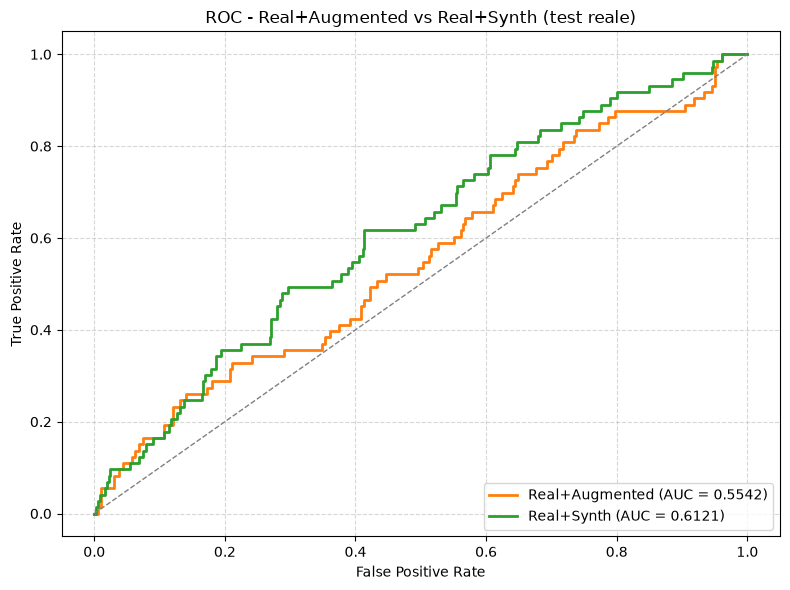

In [74]:
COLORS = {'Real+Augmented': 'tab:orange', 'Real+Synth': 'tab:green'}
fig, ax = plt.subplots(figsize=(8, 6))

#ROC per ogni modello
for nome, m in all_metrics.items():
    ax.plot(m['fpr'], m['tpr'], color=COLORS[nome], lw=2, label="%s (AUC = %.4f)" % (nome, m['auc']))

ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)                           #random guess
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')  
ax.set_title('ROC - Real+Augmented vs Real+Synth (test reale)')
ax.legend(loc='lower right'); ax.grid(True, linestyle='--', alpha=0.5)  

plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'roc_trad_aug_vs_real_synth.png')
fig.savefig(roc_path, dpi=150, bbox_inches='tight')                        
plt.show()

#### Visualizzazione Precision-Recall
- Su classi sbilanciate la PR curve è più informativa della ROC poichè non viene falsata dalla numerosità dei negativi.
- La linea grigia indica il classificatore casuale con la proporzione di positivi del test set.

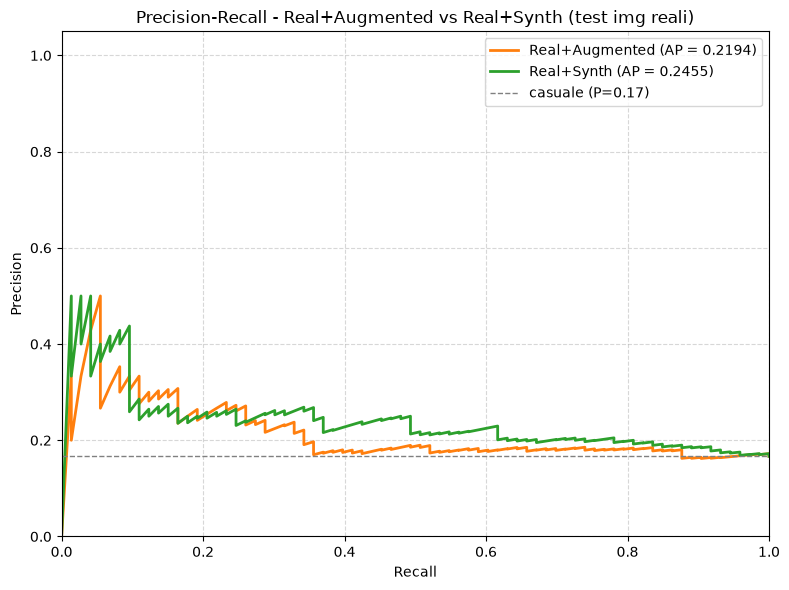

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))

#PR per ogni modello
for nome, (probs, _) in CLASSIFICATORI.items():
    prec, rec, _ = precision_recall_curve(test_true, probs)
    ap = average_precision_score(test_true, probs)
    ax.plot(rec, prec, color=COLORS[nome], lw=2, label="%s (AP = %.4f)" % (nome, ap))

baseline_pr = test_true.mean()      #proporzione di positivi nel test set          
                                   
ax.axhline(y=baseline_pr, color='gray', linestyle='--', lw=1, label="casuale (P=%.2f)" % baseline_pr)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title('Precision-Recall - Real+Augmented vs Real+Synth (test img reali)')
ax.legend(loc='upper right'); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
pr_path = os.path.join(FIGURES_DIR, 'pr_trad_aug_vs_real_synth.png')
fig.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()

#### Visualizzazione Matrici di Confusione

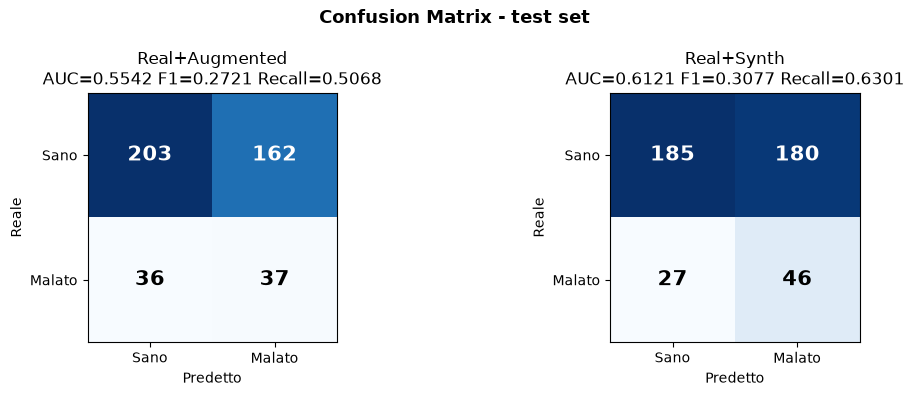

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

#cm per ogni modello
for ax, (nome, m) in zip(axes, all_metrics.items()):
    cm = confusion_matrix(test_true, m['y_pred'])
    ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])                                    #tick
    ax.set_xticklabels(['Sano', 'Malato']); ax.set_yticklabels(['Sano', 'Malato'])  
    ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
    ax.set_title("%s\nAUC=%.4f F1=%.4f Recall=%.4f" % (nome, m['auc'], m['f1'], m['recall']))
    
    #valori numerici celle
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=15, fontweight='bold', color=color)

plt.suptitle('Confusion Matrix - test set', fontsize=13, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(FIGURES_DIR, 'cm_trad_aug_vs_real_synth.png')
fig.savefig(cm_path, dpi=150, bbox_inches='tight')                            
plt.show()

#### Visualizzazione Confronto Metriche

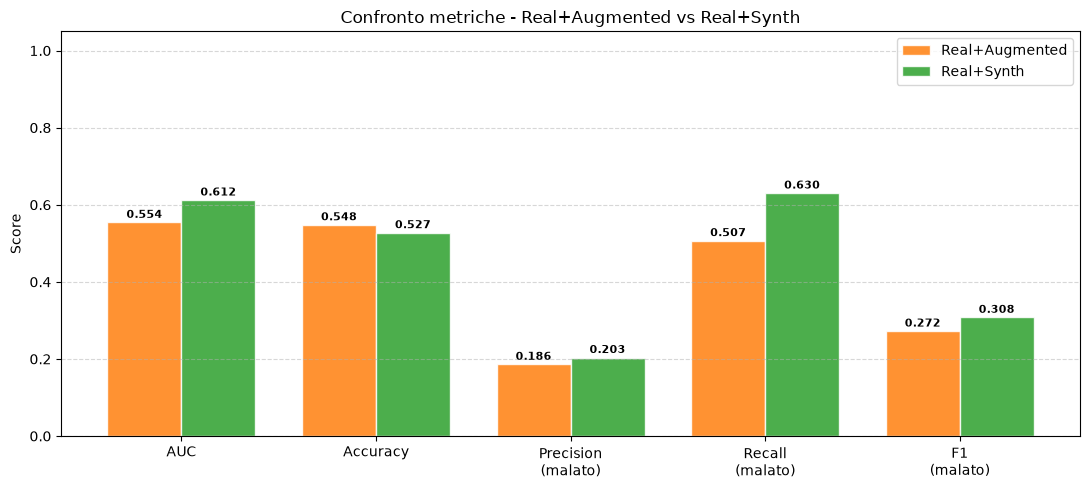

In [77]:
#grafico a barre raggruppate
metric_keys   = ['auc', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['AUC', 'Accuracy', 'Precision\n(malato)', 'Recall\n(malato)', 'F1\n(malato)']
x = np.arange(len(metric_keys)); width = 0.38
nomi = list(all_metrics.keys())                                         #iterazione su modelli trovati
fig, ax = plt.subplots(figsize=(11, 5))

#disegna barre ed etichette
for i, nome in enumerate(nomi):
    vals = [all_metrics[nome][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=nome, color=COLORS.get(nome, 'tab:blue'), alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, "%.3f" % v, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * (len(nomi) - 1) / 2); ax.set_xticklabels(metric_labels)   #centra etichette
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Confronto metriche - Real+Augmented vs Real+Synth')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)             

plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'metrics_comparison.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')                   
plt.show()

#genera e stampa tabella riassuntiva metriche
df_summary = pd.DataFrame([
    {'Configurazione': nome, 'AUC': "%.4f" % m['auc'], 'Accuracy': "%.4f" % m['accuracy'],
     'Precision': "%.4f" % m['precision'], 'Recall': "%.4f" % m['recall'],
     'F1': "%.4f" % m['f1'], 'Soglia': "%.3f" % m['threshold']}
    for nome, m in all_metrics.items()
]).set_index('Configurazione')

#salva tabella in csv
csv_path = os.path.join(TABLES_DIR, 'summary_trad_aug_vs_real_synth.csv')
df_summary.to_csv(csv_path)

#### Visualizzazione Distribuzione Probabilità Predette
- Le probabilità del test set sono separate per classe reale, la linea tratteggiata è la soglia decisionale.
- Evidenzia la separazione tra sani e malati e dove il modello commette più errori.

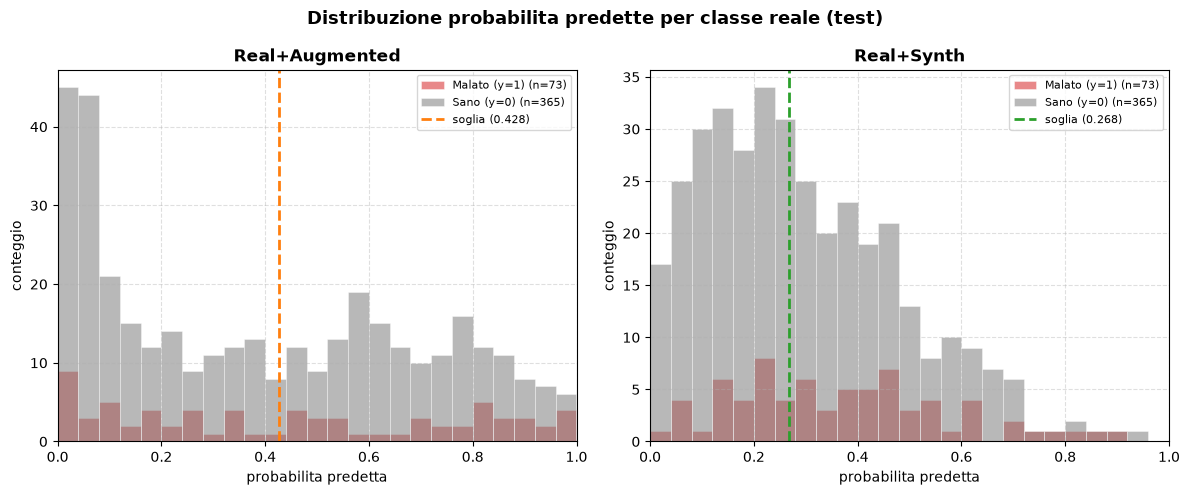

In [78]:
#distribuzione probabilita predette separata per classe reale
COLORI_CLASSE    = {1: 'tab:red', 0: 'tab:gray'}
ETICHETTE_CLASSE = {1: 'Malato (y=1)', 0: 'Sano (y=0)'}

n = len(MODELLI_ATTIVI)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)           #squeeze=False crea matrice anche con 1 modello
axes = axes[0]

#istogramma probabilita per ogni modello
for ax, nome in zip(axes, MODELLI_ATTIVI):
    probs, soglia = test_probs[nome], soglie[nome]
    for classe in (1, 0):
        maschera = (test_true == classe)
        ax.hist(probs[maschera], bins=25, range=(0, 1), alpha=0.55,
                color=COLORI_CLASSE[classe], edgecolor='white', linewidth=0.5,
                label="%s (n=%d)" % (ETICHETTE_CLASSE[classe], int(maschera.sum())))
    ax.axvline(x=soglia, color=COLORS[nome], linestyle='--', lw=2, label="soglia (%.3f)" % soglia)
    ax.set_xlim(0, 1)
    ax.set_xlabel('probabilita predetta'); ax.set_ylabel('conteggio')
    ax.set_title(nome, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Distribuzione probabilita predette per classe reale (test)', fontsize=13, fontweight='bold')
plt.tight_layout()
dist_path = os.path.join(FIGURES_DIR, 'prob_dist_trad_aug_vs_real_synth.png')
fig.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()

#### Valutazione con Bootstrap
- Si implementa un bootstrap bilanciato che ad ogni round ricampiona con reinserimento un numero uguale di casi positivi (malati) e negativi (sani), pari al numerodi osservazioni della classe minoritaria.


[Real+Augmented]
  Accuracy   0.5291 +/- 0.0420
  Precision  0.5307 +/- 0.0444
  Recall     0.5049 +/- 0.0602
  F1         0.5165 +/- 0.0486
  ROC_AUC    0.5502 +/- 0.0486

[Real+Synth]
  Accuracy   0.5644 +/- 0.0416
  Precision  0.5578 +/- 0.0376
  Recall     0.6238 +/- 0.0583
  F1         0.5882 +/- 0.0426
  ROC_AUC    0.6068 +/- 0.0484


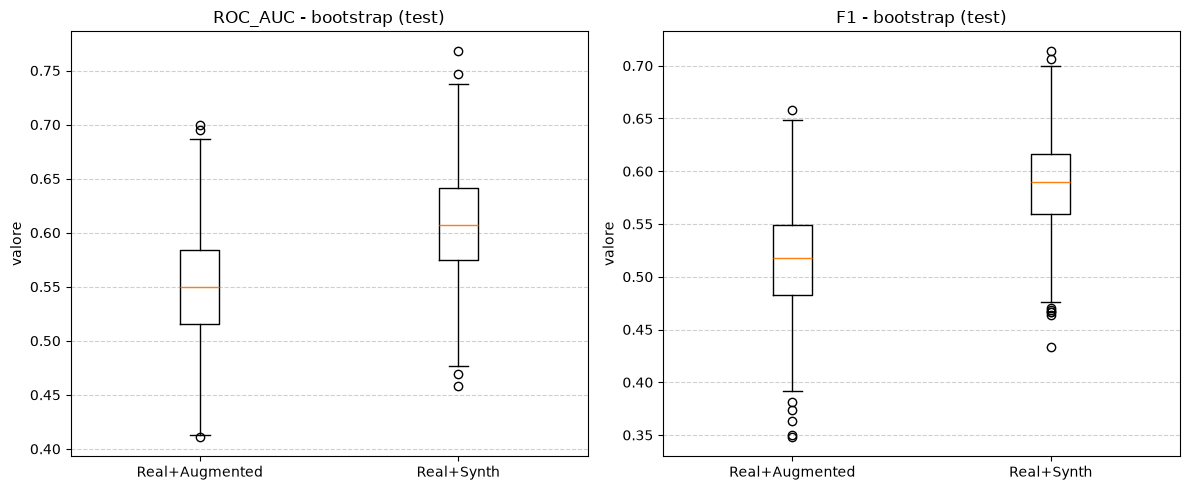

In [79]:
#calcola metriche con bootstrap per compensare sbilanciamento classi
def bootstrap_bilanciato(y_true, y_prob, threshold, n_rounds=1000, seed=SEED):
    rng = np.random.default_rng(seed)                                           #generatore casuale
    pos_idx = np.where(y_true == 1)[0]                                          #indici classe positiva
    neg_idx = np.where(y_true == 0)[0]                                          #indici classe negativa
    n = min(len(pos_idx), len(neg_idx))                                         #dimensione pari a classe minoritaria
    out = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}
    
    for _ in range(n_rounds):
        sel_pos = rng.choice(pos_idx, size=n, replace=True)
        sel_neg = rng.choice(neg_idx, size=n, replace=True)
        idx = np.concatenate([sel_pos, sel_neg])
        yt, yp = y_true[idx], y_prob[idx]
        pred = (yp >= threshold).astype(int)
        
        out['Accuracy'].append(accuracy_score(yt, pred))
        out['Precision'].append(precision_score(yt, pred, pos_label=1, zero_division=0))
        out['Recall'].append(recall_score(yt, pred, pos_label=1, zero_division=0))
        out['F1'].append(f1_score(yt, pred, pos_label=1, zero_division=0))
        out['ROC_AUC'].append(roc_auc_score(yt, yp))
    return out

#esegue bootstrap per modelli e stampa media con deviazione standard
boot = {}
for nome, (probs, thr) in CLASSIFICATORI.items():
    boot[nome] = bootstrap_bilanciato(test_true, probs, thr)
    print("\n[%s]" % nome)
    for k, v in boot[nome].items():
        print("  %-10s %.4f +/- %.4f" % (k, np.mean(v), np.std(v)))

#genera boxplot per confronto AUC e F1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['ROC_AUC', 'F1']):
    ax.boxplot([boot[n][metric] for n in CLASSIFICATORI])
    ax.set_xticklabels(list(CLASSIFICATORI.keys()))
    ax.set_title('%s - bootstrap (test)' % metric)
    ax.set_ylabel('valore'); ax.grid(True, axis='y', linestyle='--', alpha=0.6) 

plt.tight_layout()
boot_path = os.path.join(FIGURES_DIR, 'bootstrap_comparison.png')
fig.savefig(boot_path, dpi=150, bbox_inches='tight')                           
plt.show()

#### Visualizzazione Grad-CAM
Grad-CAM per confrontare le regioni d'interesse dei modelli, selezionando 4 campioni dal test set (2 Sani, 2 Malati).

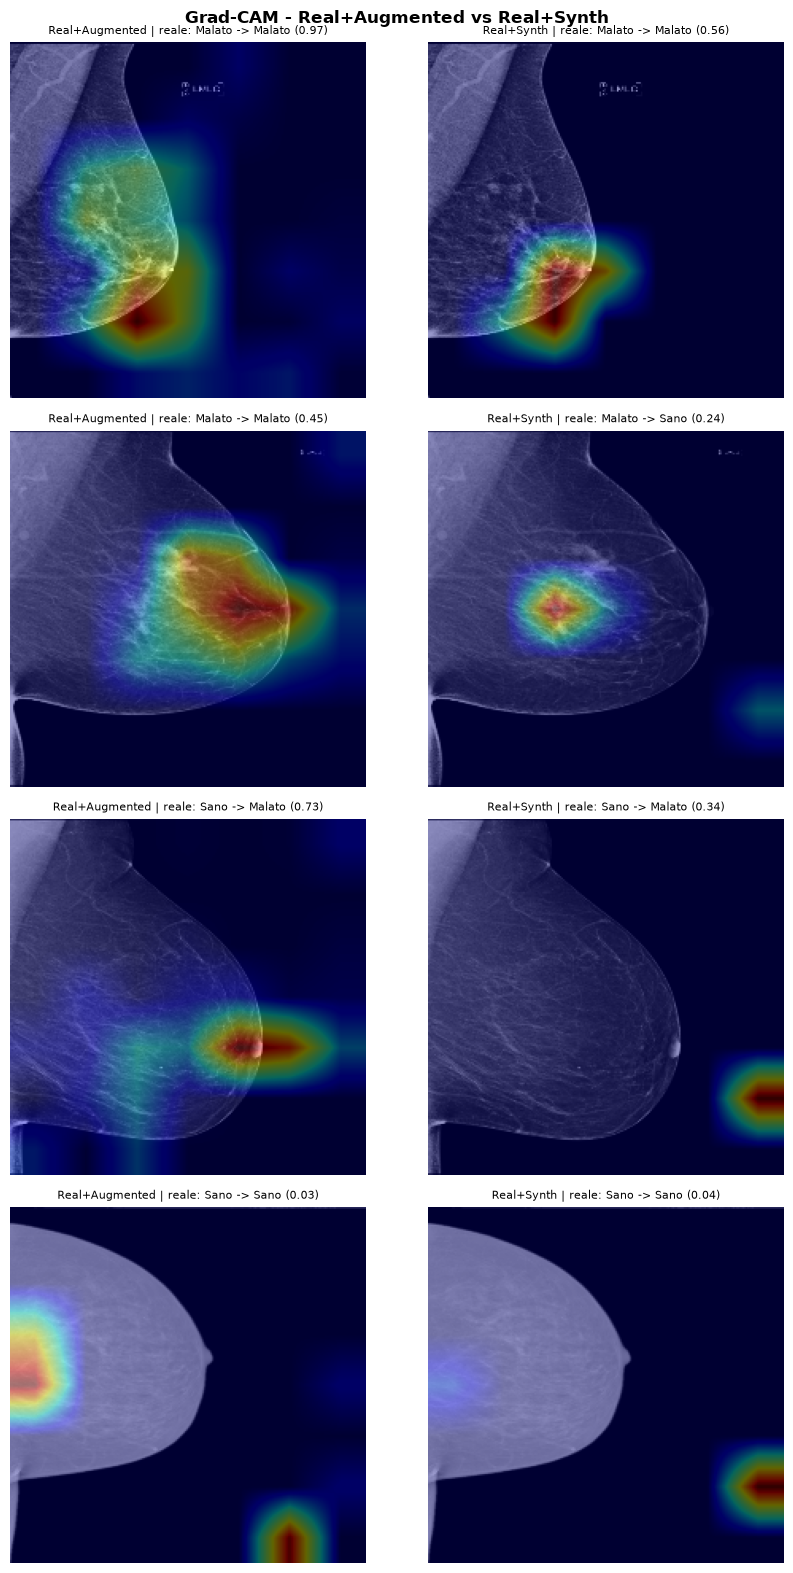

In [80]:
MEAN_NP = IMAGENET_MEAN.numpy()
STD_NP  = IMAGENET_STD.numpy()

#genera mappa di attivazione rispetto a ultima feature map
def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')                                          #layer convoluzionale base
    head_layers = [l for l in model.layers if l.name not in (model.layers[0].name, backbone.name)]  #layer classificazione
    
    #registra operazioni per il calcolo gradienti
    with tf.GradientTape() as tape:                                                 
        backbone_out = backbone(img_array, training=False)
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x

    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

#sovrappone heatmap all'immagine denormalizzata
def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * STD_NP + MEAN_NP
    img_vis = np.clip(img_vis, 0, 1)[:, :, 0]
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    
    ax.imshow(img_vis, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title, fontsize=8); ax.axis('off')                                 

#seleziona 2 campioni positivi e 2 negativi da test set
sample_pos, sample_neg = [], []
for imgs, etichette in test_ds:
    for i in range(len(imgs)):
        et = int(etichette[i].numpy())
        if et == 1 and len(sample_pos) < 2:
            sample_pos.append((imgs[i], et))
        elif et == 0 and len(sample_neg) < 2:
            sample_neg.append((imgs[i], et))
    if len(sample_pos) >= 2 and len(sample_neg) >= 2:
        break
samples = sample_pos + sample_neg

#griglia subplot per avere matrice 2D anche con singolo modello
classifiers_list = [(nome, modelli[nome], soglie[nome]) for nome in MODELLI_ATTIVI]
fig, axes = plt.subplots(len(samples), len(classifiers_list), figsize=(4.5 * len(classifiers_list), 4 * len(samples)), squeeze=False)

#predizione e disegna grad-cam per ogni campione
for row, (img, et) in enumerate(samples):
    for col, (clf_name, clf_model, clf_thr) in enumerate(classifiers_list):
        img_batch = tf.expand_dims(img, 0)                                          #aggiunge dimensione batch
        prob = float(clf_model.predict(img_batch, verbose=0)[0][0])
        pred = 'Malato' if prob >= clf_thr else 'Sano'
        heatmap = make_gradcam_heatmap(img_batch, clf_model)
        show_gradcam(img, heatmap, axes[row, col], title="%s | reale: %s -> %s (%.2f)" % (clf_name, 'Malato' if et == 1 else 'Sano', pred, prob))

plt.suptitle("Grad-CAM - Real+Augmented vs Real+Synth", fontsize=12, fontweight='bold')
plt.tight_layout()

gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_comparison.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')                             
plt.show()

#### Trade-off sostenibilita
- Lettura dei log di sostenibilità di augmentation tradizionale e generazione sintetica.
- Si calcola la % aumento inquinamento (CO2/kWh) vs % aumento prestazioni (AUC).

In [85]:
#definisce cartella base del progetto
ROOT = Path(BASE_PATH)
#mappa nome del modello a path e colore associato
ECO_SOURCES = {
    'Augmentation': {'path': ROOT / 'results' / '02_data_augmentation' / 'ecotracker' / 'augmentation_ecotracker.json', 'color': 'tab:orange'},
    'Diffusore Fine-Tuned': {'path': ROOT / 'results' / '03b_finetuning_filtered' / 'ecotracker', 'color': 'tab:green'},
    'Diffusore From Scratch': {'path': ROOT / 'results' / '04b_ldm_keras_v2_extra1361' / 'ecotracker', 'color': 'tab:red'},
}
#metriche di classificazione da calcolare
PERF_METRICS = ['auc', 'f1', 'recall']
#dizionario di sinonimi poiché i log potrebbero provengono da versioni diverse di ecotracker o script diversi, 
ECO_KEYS = {
    'energy_kwh': ['energy_kwh', 'energy', 'kwh', 'energy_consumed_kwh', 'total_energy_kwh', 'energy_consumed'],
    'co2_kg': ['co2_kg', 'co2', 'co2eq', 'co2_emissions_kg', 'emissions_kg', 'emissions', 'carbon_kg'],
    'elapsed_seconds': ['elapsed_seconds', 'elapsed', 'duration_seconds', 'duration', 'time_seconds', 'runtime_seconds'],
    'peak_ram_mb': ['peak_ram_mb', 'ram_mb', 'peak_memory_mb', 'peak_ram', 'memory_mb', 'max_ram_mb'],
}

#=========
#PROCEDURE
#=========

#formatta le percentuali
def formatta_perc(v):
    if 0 < v < 0.01:
        return "<0.01%"
    return f"{v:.2f}%"

#cerca la prima chiave valida neu json
def _estrai(rec, chiavi):
    for k in chiavi:
        if k in rec:
            try:
                v = float(rec[k])
                #evita di restituire NaN o Inf
                if np.isfinite(v):
                    return v
            except (TypeError, ValueError):
                pass
    return None

#legge file JSON o JSONL
def _record_da_file(percorso):
    try:
        txt = Path(percorso).read_text(encoding='utf-8').strip()
    except OSError:
        return []
    
    if not txt:
        return []

    #tenta di decodificare il file intero .json
    try:
        obj = json.loads(txt)
        if isinstance(obj, dict):
            return [obj]
        if isinstance(obj, list):
            return [r for r in obj if isinstance(r, dict)]
    except json.JSONDecodeError:
        pass
    
    #se fallisce assume che sia un file .jsonl
    recs = []
    for riga in txt.splitlines():
        if not riga.strip():
            continue
        try:
            obj = json.loads(riga.strip())
            if isinstance(obj, dict):
                recs.append(obj)
        except json.JSONDecodeError:
            pass
    return recs

#legge un file o una directory di log e somma i consumi totali 
def leggi_eco(percorso):
    p = Path(percorso)
    if p.is_dir():
        #ordinat tutti i .json e .jsonl
        files = sorted(f for f in p.iterdir() if f.suffix.lower() in ('.json', '.jsonl'))
    elif p.is_file():
        files = [p]
    else:
        return None
        
    e, c, t, ram = 0.0, 0.0, 0.0, 0.0
    found = False
    
    for f in files:
        for rec in _record_da_file(f):
            #estrae i dati usando la lista dei sinonimi
            ev = _estrai(rec, ECO_KEYS['energy_kwh'])
            cv = _estrai(rec, ECO_KEYS['co2_kg'])
            tv = _estrai(rec, ECO_KEYS['elapsed_seconds'])
            rv = _estrai(rec, ECO_KEYS['peak_ram_mb'])
            
            #aggrega valori
            if ev is not None:
                e += ev
                found = True
            if cv is not None:
                c += cv
                found = True
            if tv is not None:
                t += tv
            if rv is not None:
                ram = max(ram, rv) #RAM non si somma ma si cerca il picco assoluto
                
    if found:
        return {'energy_kwh': e, 'co2_kg': c, 'elapsed_seconds': t, 'peak_ram_mb': ram}
    return None

#=================
#ELABORAZIONE DATI
#=================

#raccoglie dati e provenienza per ogni modello
eco, fonte = {}, {}
for nome, cfg in ECO_SOURCES.items():
    dati = leggi_eco(cfg['path'])
    if dati:
        eco[nome] = dati
        fonte[nome] = 'REALE'
    else:
        print(f"log eco mancanti per '{nome}' -> sorgente saltata ({cfg['path']})")

#mantiene una lista aggiornata di quali modelli hanno davvero dei log validi
log_sostenibilita = [n for n in ECO_SOURCES if n in eco]
if not log_sostenibilita:
    print("nessun log di sostenibilita trovato")

#stampa riassunto
print("riepilogo emissioni\n" + "-" * 90)
print(f"{'Metodo':<24} | {'Fonte':<7} | {'Energia (kWh)':>13} | {'CO2 (kg)':>10} | {'Tempo (s)':>10} | {'RAM (MB)':>10}\n" + "-" * 90)
for n in log_sostenibilita:
    e = eco[n]
    print(f"{n:<24} | {fonte[n]:<7} | {e['energy_kwh']:13.3g} | {e['co2_kg']:10.3g} | {e['elapsed_seconds']:10.0f} | {e['peak_ram_mb']:10.0f}")
print("-" * 90)

riepilogo emissioni
------------------------------------------------------------------------------------------
Metodo                   | Fonte   | Energia (kWh) |   CO2 (kg) |  Tempo (s) |   RAM (MB)
------------------------------------------------------------------------------------------
Augmentation             | REALE   |      2.23e-05 |   7.38e-06 |         24 |        240
Diffusore Fine-Tuned     | REALE   |          2.79 |       1.07 |      35588 |       3430
Diffusore From Scratch   | REALE   |          2.88 |      0.952 |      57704 |       3719
------------------------------------------------------------------------------------------


#### Grafico consumi augmentation vs diffusion

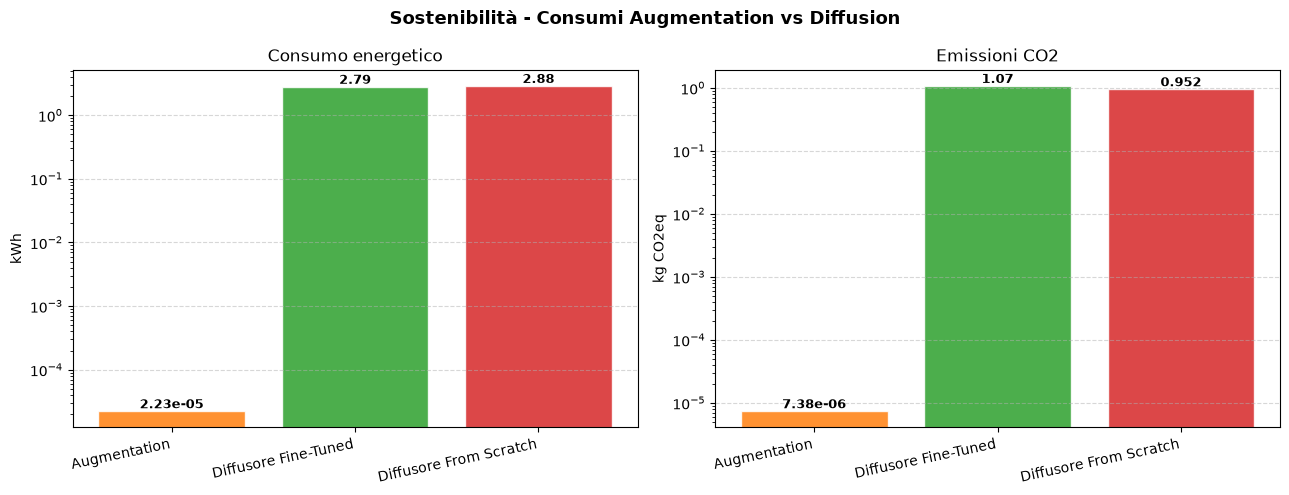

In [82]:
x = np.arange(len(log_sostenibilita))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, titolo, unita in zip(axes, ['energy_kwh', 'co2_kg'], ['Consumo energetico', 'Emissioni CO2'], ['kWh', 'kg CO2eq']):
    vals = [eco[n][key] for n in log_sostenibilita]
    colori = [ECO_SOURCES[n]['color'] for n in log_sostenibilita]
    
    bars = ax.bar(x, vals, color=colori, alpha=0.85, edgecolor='white')
    #scala logaritmica perché la diffusione consuma molto di più dell'augmentation
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_ylabel(unita)
    ax.set_title(titolo)
    xlabels = [n + (' *' if fonte[n] == 'MOCK' else '') for n in log_sostenibilita]
    ax.set_xticklabels(xlabels, rotation=12, ha='right')
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    
    #valori in cima alle barre
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3g}", ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Sostenibilità - Consumi Augmentation vs Diffusion', fontsize=13, fontweight='bold')
plt.tight_layout()
eco_path = os.path.join(FIGURES_DIR, 'eco_consumi_assoluti.png')
fig.savefig(eco_path, dpi=150, bbox_inches='tight')
plt.show()

#### Grafico trade-off emissioni vs prestazioni
Confronta le quote percentuali di emissioni di ciascun modello, con le performance di classificazione

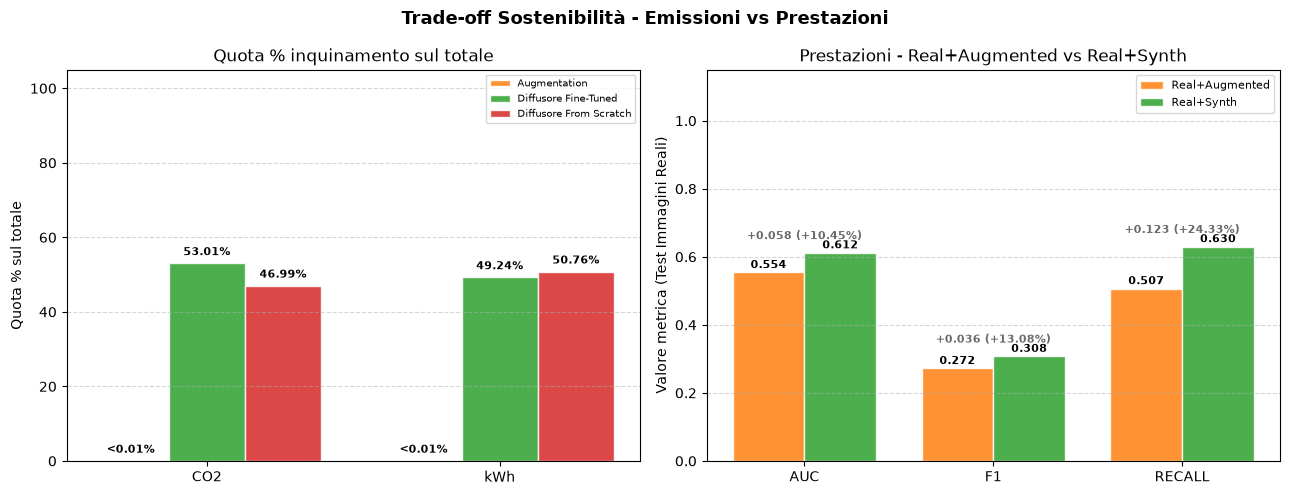

In [83]:
#calcolo consumi totali
tot_co2 = sum(eco[n]['co2_kg'] for n in log_sostenibilita)
tot_kwh = sum(eco[n]['energy_kwh'] for n in log_sostenibilita)

#calcola quote consumi
quota = {}
for n in log_sostenibilita:
    quota_co2 = (eco[n]['co2_kg'] / tot_co2 * 100) if tot_co2 else float('nan')
    quota_kwh = (eco[n]['energy_kwh'] / tot_kwh * 100) if tot_kwh else float('nan')
    quota[n] = {'co2': quota_co2, 'kwh': quota_kwh}

#calcola prestazioni modelli
if 'Real+Augmented' in all_metrics and 'Real+Synth' in all_metrics:
    pct_perf = {}
    for m in PERF_METRICS:
        val_aug = all_metrics['Real+Augmented'][m]
        val_syn = all_metrics['Real+Synth'][m]
        pct_perf[m] = (val_syn - val_aug) / val_aug * 100 if val_aug else float('nan')

    fig, (axc, axp) = plt.subplots(1, 2, figsize=(13, 5))
    xi = np.arange(2)   #??
    w = 0.26    #??
    xp = np.arange(len(PERF_METRICS))   #??
    wp = 0.38   #??
    
    #subplot costi ambientali
    for i, nome in enumerate(log_sostenibilita):
        vals = [quota[nome]['co2'], quota[nome]['kwh']]
        label = nome + (' *' if fonte[nome] == 'MOCK' else '')
        bars = axc.bar(xi + i*w, vals, w, color=ECO_SOURCES[nome]['color'], alpha=0.85, edgecolor='white', label=label)
        
        for b, v in zip(bars, vals):
            axc.text(b.get_x() + b.get_width()/2, v + 1.5, formatta_perc(v), ha='center', va='bottom', fontsize=8, fontweight='bold')
            
    axc.set_xticks(xi + w)
    axc.set_xticklabels(['CO2', 'kWh'])
    axc.set_ylim(0, 105)
    axc.set_ylabel('Quota % sul totale')
    axc.set_title('Quota % inquinamento sul totale')
    axc.legend(fontsize=7)
    axc.grid(True, axis='y', ls='--', alpha=0.5)

    #subplot prestazioni
    modelli_perf = [m for m in ('Real+Augmented', 'Real+Synth') if m in all_metrics]
    for i, nome in enumerate(modelli_perf):
        vals = [all_metrics[nome][m] for m in PERF_METRICS]
        bars = axp.bar(xp + i*wp, vals, wp, color=COLORS.get(nome, 'tab:blue'), alpha=0.85, edgecolor='white', label=nome)
        
        for b, v in zip(bars, vals):
            axp.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=8, fontweight='bold')
            
    #aggiunge annotazioni con delta
    for j, m in enumerate(PERF_METRICS):
        d = all_metrics['Real+Synth'][m] - all_metrics['Real+Augmented'][m]
        ymax = max(all_metrics['Real+Augmented'][m], all_metrics['Real+Synth'][m])
        axp.annotate(f"{d:+.3f} ({pct_perf[m]:+.2f}%)", xy=(xp[j] + wp/2, ymax + 0.04), ha='center', fontsize=8, color='dimgray', fontweight='bold')
                 
    axp.set_xticks(xp + wp/2)
    axp.set_xticklabels([m.upper() for m in PERF_METRICS])
    axp.set_ylim(0, 1.15)
    axp.set_ylabel('Valore metrica (Test Immagini Reali)')
    axp.set_title('Prestazioni - Real+Augmented vs Real+Synth')
    axp.legend(fontsize=8)
    axp.grid(axis='y', ls='--', alpha=0.5)

    fig.suptitle('Trade-off Sostenibilità - Emissioni vs Prestazioni', fontsize=13, fontweight='bold')
    plt.tight_layout()
    tradeoff_path = os.path.join(FIGURES_DIR, 'eco_tradeoff_inquinamento_vs_prestazioni.png')
    fig.savefig(tradeoff_path, dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\nservono entrambi i modelli attivi")

#### Grafico decomposizione dei costi energetici per fase

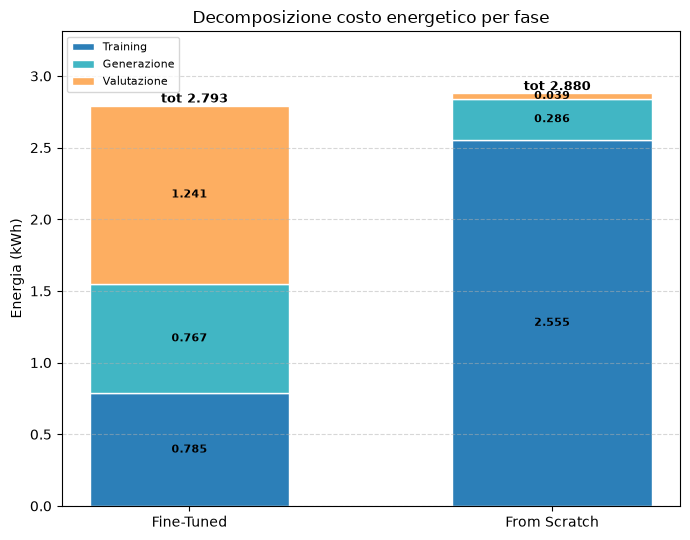

In [ ]:
#identifica il tipo di fase in funzione del nome dentro il json (differenti formati)
def classifica_fase(fname, labels):
    txt = (fname + ' ' + ' '.join(str(l) for l in labels)).lower()
    
    if any(k in txt for k in ('finetun', 'vae_training', 'ldm_training', 'training', '_train')):
        return 'Training'
    if 'pipeline' in fname.lower() or any(k in txt for k in ('generation', 'generate_raw', 'final_gen', 'gen_')):
        return 'Generazione'
    if any(k in txt for k in ('valid', 'eval', 'checkpoint')):
        return 'Valutazione'
    
    return 'Generazione'

FASI = ['Training', 'Generazione', 'Valutazione']
DIFFUSORI = [n for n in ('Diffusore Fine-Tuned', 'Diffusore From Scratch') if n in log_sostenibilita]

if DIFFUSORI:
    breakdown = {n: {f: {'energy_kwh': 0.0} for f in FASI} for n in DIFFUSORI}
    
    for n in DIFFUSORI:
        p = Path(ECO_SOURCES[n]['path'])
        
        #gestisce sia cartelle con più JSON che percorsi diretti a file singoli
        if p.is_dir():
            files = sorted(x for x in p.iterdir() if x.suffix.lower() in ('.json', '.jsonl'))
        elif p.is_file():
            files = [p]
        else:
            continue
        
        for f in files:
            recs = _record_da_file(f)
            labels = [r.get('label', r.get('phase', '')) for r in recs]
            fase = classifica_fase(f.name, labels)
            
            #estrae usando la lista di sinonimi
            for r in recs:
                val = _estrai(r, ECO_KEYS['energy_kwh'])
                if val:
                    breakdown[n][fase]['energy_kwh'] += val

    col_fase = {'Training': '#2c7fb8', 'Generazione': '#41b6c4', 'Valutazione': '#fdae61'}
    x_diff = np.arange(len(DIFFUSORI))
    bottom = np.zeros(len(DIFFUSORI))
    
    fig, ax_decomp = plt.subplots(figsize=(7, 5.5))
    
    for fase in FASI:
        vals = np.array([breakdown[n][fase]['energy_kwh'] for n in DIFFUSORI])
        bars = ax_decomp.bar(x_diff, vals, 0.55, bottom=bottom, label=fase, color=col_fase[fase], edgecolor='white')
        
        for xi, (b, v) in enumerate(zip(bars, vals)):
            #mostra il testo solo se l'energia è misurabile
            if v > 0.001:
                ax_decomp.text(b.get_x() + b.get_width()/2, bottom[xi] + v/2, f"{v:.3f}", ha='center', va='center', fontsize=8, fontweight='bold')
        bottom += vals
        
    for xi, b in enumerate(bottom):
        ax_decomp.text(xi, b + 0.001, f"  tot {b:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax_decomp.set_xticks(x_diff)
    ax_decomp.set_xticklabels([n.replace('Diffusore ', '') for n in DIFFUSORI])
    ax_decomp.set_ylabel('Energia (kWh)')
    ax_decomp.set_title('Decomposizione costo energetico per fase')
    ax_decomp.legend(fontsize=8)
    ax_decomp.grid(True, axis='y', ls='--', alpha=0.5)
    ax_decomp.margins(y=0.15)
    
    plt.tight_layout()
    adv_path = os.path.join(FIGURES_DIR, 'eco_decomposizione_fasi.png')
    fig.savefig(adv_path, dpi=150, bbox_inches='tight')
    plt.show()